# 3-Pulse Mach-Zehnder Interferometer with Temperature — New Pulse API

Replicates `mach_zehnder_with_temperature.ipynb` using the new event-based pulse sequence API
(`build_mach_zehnder_pulse_sequence` + `calculate_excited_fraction_for_pulse_sequence`).

Demonstrates a $\pi/2 - \pi - \pi/2$ Mach-Zehnder atom interferometer sequence.

Pulse phases: $0$, $\phi$, $4\phi$ respectively, with $\phi$ scanned from $0$ to $2\pi$.

Repeat with detunings drawn from a distribution based on a Maxwell-Boltzmann distribution of velocities at $T = 200\,\mathrm{nK}$.

A final comparison cell verifies numerical equivalence with the old low-level implementation.

In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

import lmt_sim.version_info as vs

from lmt_sim.lmt_sequence import (
    build_mach_zehnder_pulse_sequence,
    calculate_excited_fraction_for_pulse_sequence,
)
from lmt_sim.lmt_simulation import (
    RECOIL_FREQUENCY_HZ,
    RABI_FREQ,
)

%matplotlib inline

In [3]:
# np.random.seed(42)

T_FREE = 200e-6  # Free evolution time between pulses

MASS_ATOM = constants.atomic_mass * 87

# Draw velocities from 1D Maxwell-Boltzmann distribution at T
# 1D MB is a Gaussian with sigma_v = sqrt(k_B T / m)
N_ATOMS = 200
TEMPERATURE = 200e-9

sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
velocities = np.random.normal(0, sigma_v, size=N_ATOMS)
phi_values = np.linspace(0, 2 * np.pi, 101)

In [4]:
from tqdm import tqdm


def calc_mz_excitation_pulse_api(
    phi,
    initial_velocity_z=0.0,
    time_between_pulses=T_FREE,
):
    pulse_sequence = build_mach_zehnder_pulse_sequence(
        phi=phi,
        detuning_hz=RECOIL_FREQUENCY_HZ,
        time_between_pulses=time_between_pulses,
        rabi_frequency=RABI_FREQ,
        k=+1,
    )
    return calculate_excited_fraction_for_pulse_sequence(
        pulse_sequence,
        initial_velocity_z=initial_velocity_z,
    )


# Simulate for each atom velocity
excitation_curves = np.empty((N_ATOMS, len(phi_values)))

for ind_atom, velocity in enumerate(tqdm(velocities, desc="Simulating atoms")):
    excitation_fractions = np.empty_like(phi_values)

    for ind_phi, phi in enumerate(phi_values):
        excitation_fractions[ind_phi] = calc_mz_excitation_pulse_api(
            phi,
            initial_velocity_z=velocity,
            time_between_pulses=T_FREE,
        )

        if excitation_fractions[ind_phi] < 0 or excitation_fractions[ind_phi] > 1:
            print(
                f"Warning: Unphysical excitation fraction {excitation_fractions[ind_phi]:.3f} "
                f"for velocity {velocity:.2f} m/s, phi={phi:.2f}"
            )

    excitation_curves[ind_atom, :] = excitation_fractions

mean_excitation = np.mean(excitation_curves, axis=0)
std_excitation = np.std(excitation_curves, axis=0)

Simulating atoms:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating atoms:   1%|          | 2/200 [00:00<00:13, 14.55it/s]

Simulating atoms:   2%|▏         | 4/200 [00:00<00:12, 15.79it/s]

Simulating atoms:   3%|▎         | 6/200 [00:00<00:11, 16.49it/s]

Simulating atoms:   4%|▍         | 8/200 [00:00<00:11, 16.83it/s]

...

Simulating atoms:  97%|█████████▋| 194/200 [00:11<00:00, 14.90it/s]

Simulating atoms:  98%|█████████▊| 196/200 [00:11<00:00, 14.97it/s]

Simulating atoms:  99%|█████████▉| 198/200 [00:11<00:00, 15.46it/s]

Simulating atoms: 100%|██████████| 200/200 [00:11<00:00, 15.84it/s]

Simulating atoms: 100%|██████████| 200/200 [00:11<00:00, 17.06it/s]

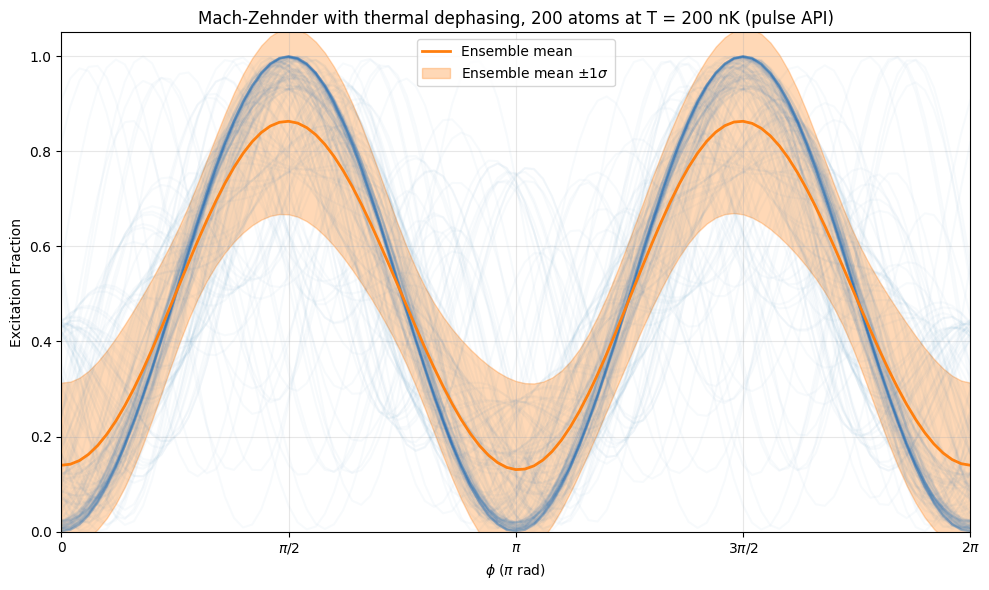

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot individual traces with low alpha
for curve in excitation_curves:
    ax.plot(phi_values / np.pi, curve, color="tab:blue", alpha=0.03)

# Plot mean and std
ax.plot(
    phi_values / np.pi,
    mean_excitation,
    color="tab:orange",
    lw=2,
    label="Ensemble mean",
)
ax.fill_between(
    phi_values / np.pi,
    mean_excitation - std_excitation,
    mean_excitation + std_excitation,
    color="tab:orange",
    alpha=0.3,
    label=r"Ensemble mean $\pm 1\sigma$",
)

ax.set_xlabel(r"$\phi$ ($\pi$ rad)")
ax.set_ylabel("Excitation Fraction")
ax.set_title(
    f"Mach-Zehnder with thermal dephasing, {N_ATOMS} atoms at T = {TEMPERATURE*1e9:.0f} nK (pulse API)"
)
ax.set_xticks([0, 0.5, 1, 1.5, 2], ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.05)
vs.tag_plot(small=True)
fig.tight_layout()

## Equivalence check

Compare the new pulse API against the old low-level implementation from `mach_zehnder_with_temperature.ipynb`
for a sample of velocities and phase values. Results should agree to floating-point precision.

In [6]:
from lmt_sim.lmt_simulation import (
    make_atom_states,
    transform_state_vector,
    propagate_states_in_borde_representation,
    pulse_interaction_in_borde_representation,
    calculate_ground_and_excited_probabilities,
    K_WAVEVECTOR,
    TRANSITION_FREQUENCY,
    T_PI,
)


def calc_mz_excitation_old_api(
    phi,
    detuning_hz,
    initial_velocity_z=0.0,
    time_between_pulses=T_FREE,
):
    """Old low-level implementation, copied verbatim from mach_zehnder_with_temperature.ipynb."""
    state = make_atom_states(
        initial_velocity_z=initial_velocity_z,
        c0=1,
        c1=0,
    )

    omega_laser = 2 * np.pi * (TRANSITION_FREQUENCY + detuning_hz)
    current_time = 0.0

    state = transform_state_vector(
        state,
        omega_laser=omega_laser,
        t=current_time,
        z=0.0,
        vz=initial_velocity_z,
        inverse=False,
    )

    # First pi/2 pulse, phase 0
    state = pulse_interaction_in_borde_representation(
        state,
        pulse_detuning=detuning_hz,
        t_pulse=T_PI / 2,
        pulse_rabi_freq=RABI_FREQ,
        pulse_phase=0.0,
        k_sign=+1,
        k_wavevector=K_WAVEVECTOR,
        vz=initial_velocity_z,
    )
    current_time += T_PI / 2

    if time_between_pulses > 0:
        state = propagate_states_in_borde_representation(
            state,
            time_of_propegation=time_between_pulses,
            detuning_hz=detuning_hz,
            vz=initial_velocity_z,
            k_wavevector=K_WAVEVECTOR,
        )
        current_time += time_between_pulses

    state = pulse_interaction_in_borde_representation(
        state,
        pulse_detuning=detuning_hz,
        t_pulse=T_PI,
        pulse_rabi_freq=RABI_FREQ,
        pulse_phase=phi,
        k_sign=+1,
        k_wavevector=K_WAVEVECTOR,
        vz=initial_velocity_z,
    )
    current_time += T_PI

    if time_between_pulses > 0:
        state = propagate_states_in_borde_representation(
            state,
            time_of_propegation=time_between_pulses,
            detuning_hz=detuning_hz,
            vz=initial_velocity_z,
            k_wavevector=K_WAVEVECTOR,
        )
        current_time += time_between_pulses

    state = pulse_interaction_in_borde_representation(
        state,
        pulse_detuning=detuning_hz,
        t_pulse=T_PI / 2,
        pulse_rabi_freq=RABI_FREQ,
        pulse_phase=4 * phi,
        k_sign=+1,
        k_wavevector=K_WAVEVECTOR,
        vz=initial_velocity_z,
    )
    current_time += T_PI / 2

    state = transform_state_vector(
        state,
        omega_laser=omega_laser,
        t=current_time,
        z=0.0,
        vz=initial_velocity_z,
        inverse=True,
    )

    ground_prob, excited_prob = calculate_ground_and_excited_probabilities(state)
    total_prob = ground_prob + excited_prob
    return excited_prob / total_prob

In [7]:
# Compare on a grid of (velocity, phi) pairs
test_velocities = np.linspace(-0.01, 0.01, 5)  # m/s
test_phi_values = np.linspace(0, 2 * np.pi, 21)

max_abs_diff = 0.0
all_old = []
all_new = []

for vz in test_velocities:
    for phi in test_phi_values:
        old = calc_mz_excitation_old_api(phi, detuning_hz=RECOIL_FREQUENCY_HZ, initial_velocity_z=vz)
        new = calc_mz_excitation_pulse_api(phi, initial_velocity_z=vz)
        all_old.append(old)
        all_new.append(new)
        diff = abs(old - new)
        if diff > max_abs_diff:
            max_abs_diff = diff

all_old = np.array(all_old)
all_new = np.array(all_new)

print(f"Max absolute difference (old vs new): {max_abs_diff:.2e}")
print(f"Mean absolute difference:             {np.mean(np.abs(all_old - all_new)):.2e}")
assert max_abs_diff < 1e-10, f"APIs disagree: max diff = {max_abs_diff:.2e}"
print("PASS: old and new APIs agree to < 1e-10")

Max absolute difference (old vs new): 0.00e+00
Mean absolute difference:             0.00e+00
PASS: old and new APIs agree to < 1e-10


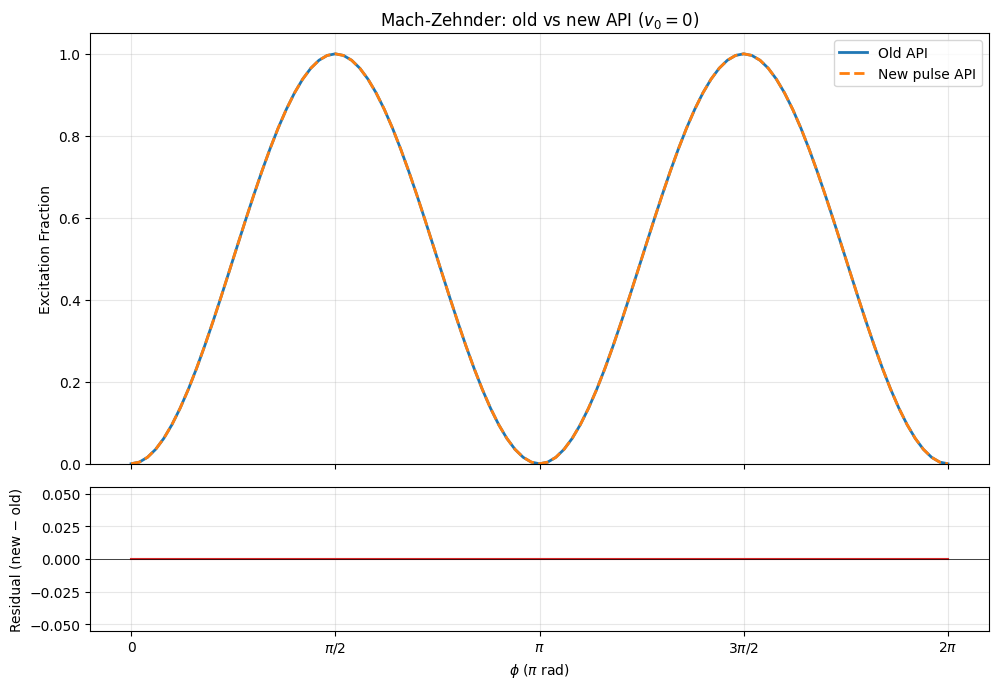

In [8]:
# Visual comparison: overlay old vs new for a single atom at zero velocity
old_curve = np.array([calc_mz_excitation_old_api(phi, detuning_hz=RECOIL_FREQUENCY_HZ) for phi in phi_values])
new_curve = np.array([calc_mz_excitation_pulse_api(phi) for phi in phi_values])

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(phi_values / np.pi, old_curve, lw=2, label="Old API", color="tab:blue")
axes[0].plot(phi_values / np.pi, new_curve, lw=2, label="New pulse API", color="tab:orange", linestyle="--")
axes[0].set_ylabel("Excitation Fraction")
axes[0].set_title("Mach-Zehnder: old vs new API ($v_0 = 0$)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

residual = new_curve - old_curve
axes[1].plot(phi_values / np.pi, residual, color="tab:red", lw=1.5)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_ylabel("Residual (new − old)")
axes[1].set_xlabel(r"$\phi$ ($\pi$ rad)")
axes[1].set_xticks([0, 0.5, 1, 1.5, 2], ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axes[1].grid(True, alpha=0.3)

vs.tag_plot(small=True)
fig.tight_layout()